In [11]:
import json
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

CHOICES = ["A", "B", "C", "D"]


def load_data(path, key="forget_mcqa_prob"):
    with open(path, "r") as f:
        data = json.load(f)

    values = data[key]["value_by_index"]

    y_true = []
    y_pred = []
    probs = []

    for k in values:
        item = values[k]

        y_true.append(item["label"])
        y_pred.append(item["generated choice"])
        probs.append(item["prob"])

    probs = np.array(probs)

    return y_true, y_pred, probs


# -----------------------
# Accuracy + F1
# -----------------------

def compute_accuracy_f1(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return acc, f1


# -----------------------
# Brier score (multiclass)
# -----------------------

def compute_brier(y_true, probs):

    y_true_idx = np.array([CHOICES.index(y) for y in y_true])

    one_hot = np.zeros_like(probs)
    one_hot[np.arange(len(y_true_idx)), y_true_idx] = 1

    brier = np.mean(np.sum((probs - one_hot) ** 2, axis=1))

    return brier


# -----------------------
# ECE / MCE
# -----------------------

def compute_ece_mce(y_true, probs, n_bins=10):

    y_true_idx = np.array([CHOICES.index(y) for y in y_true])

    conf = np.max(probs, axis=1)
    pred = np.argmax(probs, axis=1)

    correct = (pred == y_true_idx).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0
    mce = 0.0

    for i in range(n_bins):

        mask = (conf >= bins[i]) & (conf < bins[i + 1])

        if np.sum(mask) == 0:
            continue

        acc_bin = np.mean(correct[mask])
        conf_bin = np.mean(conf[mask])

        gap = abs(acc_bin - conf_bin)

        ece += np.sum(mask) / len(conf) * gap
        mce = max(mce, gap)

    return ece, mce

# -----------------------
# Reliability Diagram
# -----------------------

import matplotlib.pyplot as plt
import numpy as np

CHOICES = ["A", "B", "C", "D"]


def plot_reliability_diagram(y_true, probs, n_bins=10):

    y_true_idx = np.array([CHOICES.index(y) for y in y_true])

    conf = np.max(probs, axis=1)
    pred = np.argmax(probs, axis=1)

    correct = (pred == y_true_idx).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)

    bin_acc = []
    bin_conf = []
    bin_count = []

    for i in range(n_bins):

        mask = (conf >= bins[i]) & (conf < bins[i + 1])

        if np.sum(mask) == 0:
            bin_acc.append(0)
            bin_conf.append(0)
            bin_count.append(0)
            continue

        bin_acc.append(np.mean(correct[mask]))
        bin_conf.append(np.mean(conf[mask]))
        bin_count.append(np.sum(mask))

    bin_acc = np.array(bin_acc)
    bin_conf = np.array(bin_conf)
    bin_count = np.array(bin_count)

    # ----- plot -----

    plt.figure()

    # bars = accuracy
    plt.bar(
        np.linspace(0.05, 0.95, n_bins),
        bin_acc,
        width=0.08,
        alpha=0.6,
        label="Accuracy",
    )

    # confidence line
    plt.plot(
        np.linspace(0.05, 0.95, n_bins),
        bin_conf,
        marker="o",
        label="Confidence",
    )

    # perfect calibration
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect")

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")

    plt.legend()
    plt.show()


# -----------------------
# MAIN
# -----------------------

def print_metrics_and_plot(path):
    
    for key in ["forget_mcqa_prob", "retain_mcqa_prob"]:
        print(f"--- {key} ---")
        y_true, y_pred, probs = load_data(path, key=key)

        acc, f1 = compute_accuracy_f1(y_true, y_pred)
        brier = compute_brier(y_true, probs)
        ece, mce = compute_ece_mce(y_true, probs, n_bins=10)

        print("Accuracy:", acc)
        print("F1:", f1)
        print("Brier:", brier)
        print("ECE:", ece)
        print("MCE:", mce)
        
        plot_reliability_diagram(y_true, probs, n_bins=10)

=== relu_Llama-3.2-1B-Instruct_full_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.275
F1: 0.23157690262953418
Brier: 1.0908492259918376
ECE: 0.43466744050383566
MCE: 0.768486758073171


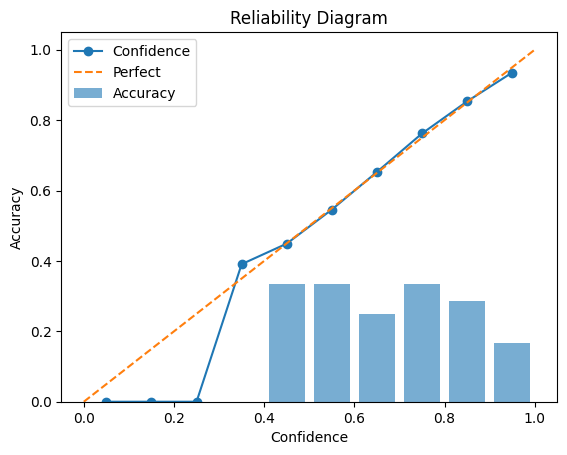

--- retain_mcqa_prob ---
Accuracy: 0.2631977772164688
F1: 0.1407672819904934
Brier: 1.1491766240873176
ECE: 0.5193650141663249
MCE: 0.6677646543093667


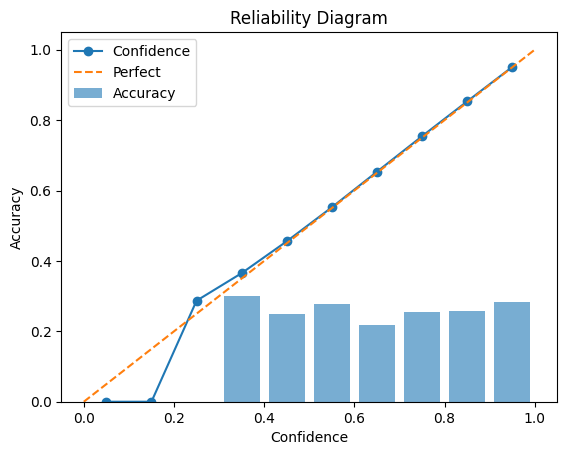

In [12]:
path_template = "/DATA3/divyaksh/Projects/inseq_testing/open-unlearning/saves/eval/{task_name}/RELU_EVAL.json"
tasks = [
    "relu_Llama-3.2-1B-Instruct_full_retain99",
    # "relu_Llama-3.2-1B-Instruct_full_retain95",
    # "relu_Llama-3.2-1B-Instruct_full_retain90",
    # "relu_Llama-3.2-1B-Instruct_pretrained_retain99",
    # "relu_Llama-3.2-1B-Instruct_pretrained_retain95",
    # "relu_Llama-3.2-1B-Instruct_pretrained_retain90",
    # "relu_Llama-3.2-1B-Instruct_retain90",
    # "relu_Llama-3.2-1B-Instruct_retain95",
    # "relu_Llama-3.2-1B-Instruct_retain99",
]

for task in tasks:
    print(f"=== {task} ===")
    print_metrics_and_plot(path_template.format(task_name=task))
